In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from lgdo import lh5

/tmp/ipykernel_303727/209162716.py:4: DeprecationWarning: lgdo.lh5 has moved to its own package, legend-lh5io. Please replace 'import lgdo.lh5' with 'import lh5'. lgdo.lh5 will be removed in a future release.
  from lgdo import lh5


In [2]:
def draw_p_values_lh5(filename, title='', sensitivity=False, confidence=0.68, is_limit=False, digits=1, bounds=True, ax=None):
    """Load statistical analysis output and draw p-value vs. survival fraction plots.
    Optional: Draw sensitivity curve as well."""
    # load lh5 file into variables
    MLE             = lh5.read("fc_results/MLE_eps_s", filename)[0]
    para_range      = np.array(lh5.read("fc_results/para_range", filename))
    p_value_range   = np.array(lh5.read("fc_results/p_value_range", filename))
    median_H0       = np.array(lh5.read("fc_results/median_H0", filename))
    bound_68_lower  = np.array(lh5.read("fc_results/bound_68_lower", filename))
    bound_68_higher = np.array(lh5.read("fc_results/bound_68_higher", filename))
    bound_90_lower  = np.array(lh5.read("fc_results/bound_90_lower", filename))
    bound_90_higher = np.array(lh5.read("fc_results/bound_90_higher", filename))

    # create figure and draw the data
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure
    ax.set_xlabel('Survival Fraction (%)')
    ax.set_ylabel(r'$p$-value')
    ax.set_ylim(0, 1)

    ax.scatter(para_range, p_value_range, label='Observed')
    
    # fit a linear spline to the data and plot it
    gamma = 1-confidence
    tck = sp.interpolate.splrep(para_range[1:], p_value_range[1:]-gamma, s=0, k=1)
    spline_x = np.linspace(para_range.min(), para_range.max(), int(1e3))
    ax.plot(spline_x, sp.interpolate.splev(spline_x, tck)+gamma, alpha=0.3, marker=None, ls='dashed') #label='Obs. interpolation',
    ax.set_xlim(para_range.min(), para_range.max())

    def get_roots(tck, gamma):
        """Interpolate and get roots."""
        ppoly = sp.interpolate.PPoly.from_spline(tck)
        roots = ppoly.roots(extrapolate=False)
        ax.vlines(roots, np.zeros_like(roots), sp.interpolate.splev(roots, tck)+gamma, color='black', ls='dashed', label="Conf. interval")
        return roots

    def draw_confidence_interval(tck, gamma):
        """After drawing the p-values, calculate the confidence intervals (either 68% or 90%), print and draw them into the plot."""
        roots = get_roots(tck, gamma)
        print('MLE: {0} +{1} -{2} %'.format(
            round(MLE*100, digits),
            round((MLE - roots[0])*100, digits),
            round((roots[1] - MLE)*100, digits)
        ))
        print('{0}% confidence interval: {1} %'.format((1-gamma)*100, np.round(roots, 4)*100))

    def draw_limit(tck, gamma):
        """Calculate the upper limit, print and draw it."""
        roots = get_roots(tck, gamma)
        print('{0}% upper limit: {1} %'.format((1-gamma)*100, np.round(roots, 4)*100))

    if not is_limit:
        draw_confidence_interval(tck, gamma)
    else:
        draw_limit(tck, gamma)

    # in case we are also interested in the sensitivity of the measurement (mostly when we quote a limit)
    if sensitivity:
        ax.scatter(para_range, median_H0, label='Median expected')
        # fit a linear spline to the data and plot it
        H0_tck = sp.interpolate.splrep(para_range[1:], median_H0[1:]-gamma, s=0, k=1)
        ax.plot(spline_x, sp.interpolate.splev(spline_x, H0_tck)+gamma, alpha=0.3, #label='Exp. interpolation',
                marker=None, ls='dashed', color="tab:orange")
        if bounds:
            ax.fill_between(para_range, bound_68_lower, bound_68_higher, color="tab:orange", alpha=0.2)#, label=r"68% containment")
            ax.fill_between(para_range, bound_90_lower, bound_90_higher, color="tab:orange", alpha=0.1)#, label=r"90% containment")

        # get 90% CL median sensitivity
        #draw_limit(sp.interpolate.splrep(para_range[1:], median_H0[1:]-0.1, s=0, k=1), 0.1)

    ax.set_xticks(np.round(ax.get_xticks(), 3))
    ax.set_xticklabels(ax.get_xticks()*100)
    ax.legend(title=title)    
    return fig, ax

# K42 suppressions

In [14]:
plt.style.use("/mnt/atlas01/users/vogl/style/phd_style/phd_thesis.mplstyle")
candidate= 'bare_aoe_ic_s100ns_mw5'
path = '/mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/results/'+candidate+'.lh5'

# Active techniques

## Bare

### Bare A/E (default estimator)

MLE: 0.51 +0.12 -0.11 %
68.0% confidence interval: [0.39 0.62] %


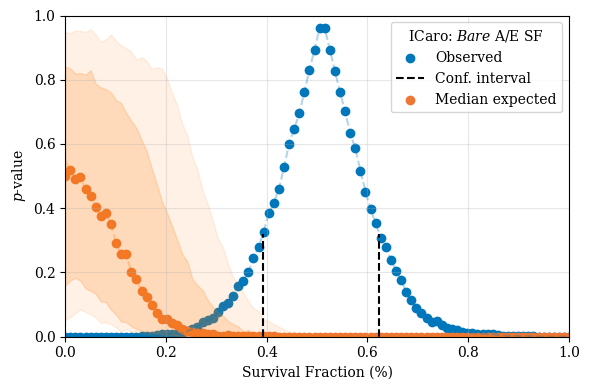

In [15]:
fig, axes = plt.subplots(figsize=(6, 4))
# draw_p_values_lh5(path, ax=axes[0])
# axes[0].legend(title=r"4/D: $\it{Bare}$ A/E SF", loc="upper left")
draw_p_values_lh5(path, title=r'ICaro: $\it{Bare}$ A/E SF', sensitivity=True, 
                  is_limit=False, digits=2, ax=axes)
fig.tight_layout()
    # fig.savefig("../plots/phd/pvals_bare_aoe_combined.pdf")


### Bare A/E (A_max)

### Bare A/E (A_tri)

### Bare LAr veto

LH5DecodeError: while opening file /mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/results/bare_aoe_ic_s500ns_mw3_diff.lh5bare_lar_bege.lh5 for decoding: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/atlas02/users/leoli/AoverE_analysis/sit_analysis/K42_sf/results/bare_aoe_ic_s500ns_mw3_diff.lh5bare_lar_bege.lh5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

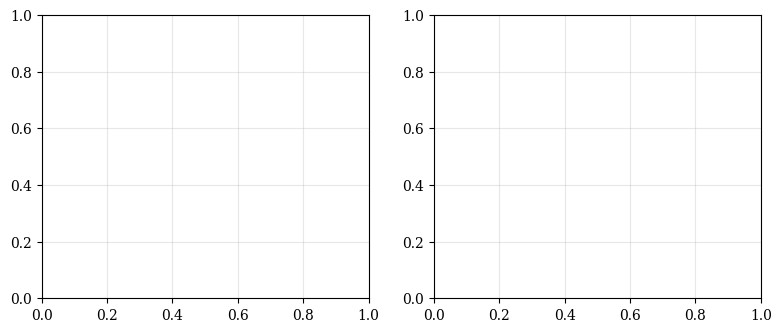

In [5]:
fig, axes = plt.subplots(ncols=2)
fig, ax = draw_p_values_lh5(path+'bare_lar_bege.lh5', title=r'4/D: $\it{Bare}$ LAr veto SF', ax=axes[0])
fig, ax = draw_p_values_lh5(path+'bare_lar_ic.lh5', title=r'ICaro: $\it{Bare}$ LAr veto SF', ax=axes[1])
fig.tight_layout()

### Bare A/E (default) and LAr veto combined

In [ ]:
fig, axes = plt.subplots(ncols=2)
fig, ax = draw_p_values_lh5(path+'bare_aoelar_bege.lh5', title=r'4/D: A/E & LAr veto SF', ax=axes[0],
                            digits=1)
fig, ax = draw_p_values_lh5(path+'bare_aoelar_ic.lh5', title=r'ICaro: A/E & LAr veto SF', ax=axes[1],
                            sensitivity=True, digits=2)
fig.tight_layout()

## PEN-enclosed

### PEN-enclosed A/E (default estimator)

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'pen_aoe_bege.lh5', title=r"4/D: $\it{PEN}$-$\it{enclosed}$ A/E SF", ax=axes[0])
draw_p_values_lh5(path+'pen_aoe_ic.lh5', title=r'ICaro: $\it{PEN}$-$\it{enclosed}$ A/E SF', sensitivity=True, 
                  is_limit=False, digits=1, ax=axes[1])
fig.tight_layout()

### PEN-enclosed LAr veto

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'pen_lar_bege.lh5', title=r"4/D: $\it{PEN}$-$\it{enclosed}$ LAr veto SF", ax=axes[0])
draw_p_values_lh5(path+'pen_lar_ic.lh5', title=r'ICaro: $\it{PEN}$-$\it{enclosed}$ LAr veto SF', ax=axes[1])
fig.tight_layout()

### PEN-enclosed A/E and LAr veto combined

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'pen_aoelar_bege.lh5', title=r"4/D: $\it{PEN}$-$\it{enclosed}$ A/E & LAr veto SF", ax=axes[0])
draw_p_values_lh5(path+'pen_aoelar_ic.lh5', title=r'ICaro: $\it{PEN}$-$\it{enclosed}$ A/E & LAr veto SF', sensitivity=True, 
                  is_limit=False, digits=1, ax=axes[1])
fig.tight_layout()

## NMS-enclosed

### NMS-enclosed A/E

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'nms_aoe_bege.lh5', title=r"4/D: $\it{NMS}$-$\it{enclosed}$ A/E SF", ax=axes[0])
draw_p_values_lh5(path+'nms_aoe_ic.lh5', title=r'ICaro: $\it{NMS}$-$\it{enclosed}$ A/E SF', sensitivity=True, 
                  is_limit=False, digits=1, ax=axes[1])
fig.tight_layout()

### NMS-enclosed LAr veto

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'nms_lar_bege.lh5', title=r"4/D: $\it{NMS}$-$\it{enclosed}$ LAr veto SF", ax=axes[0])
draw_p_values_lh5(path+'nms_lar_ic.lh5', title=r'ICaro: $\it{NMS}$-$\it{enclosed}$ LAr veto SF', ax=axes[1])
fig.tight_layout()

### NMS-enclosed A/E and LAr veto combined

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'nms_aoelar_bege.lh5', title=r"4/D: $\it{NMS}$-$\it{enclosed}$ A/E & LAr veto SF", ax=axes[0])
draw_p_values_lh5(path+'nms_aoelar_ic.lh5', title=r'ICaro: $\it{NMS}$-$\it{enclosed}$ A/E & LAr veto SF', sensitivity=True, 
                  is_limit=False, digits=1, ax=axes[1])
fig.tight_layout()

# Passive techniques

## PEN-enclosed passive

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'bare2pen_qcm_bege.lh5', title=r"4/D: $\it{PEN}$-$\it{enclosed}$ passive SF", ax=axes[0])
draw_p_values_lh5(path+'bare2pen_qcm_ic.lh5', title=r'ICaro: $\it{PEN}$-$\it{enclosed}$ passive SF', ax=axes[1])
fig.tight_layout()

## NMS-enclosed passive

In [ ]:
fig, axes = plt.subplots(ncols=2)
#draw_p_values_lh5(path+'bare2nms_qcm_bege.lh5', title=r"4/D: $\it{NMS}$-$\it{enclosed}$ passive SF", ax=axes[0])
draw_p_values_lh5(path+'bare2nms_qcm_ic.lh5', title=r'ICaro: $\it{NMS}$-$\it{enclosed}$ passive SF', ax=axes[1])
fig.tight_layout()

# Passive & active combined

## PEN-enclosed passive + A/E + LAr veto

In [ ]:
fig, axes = plt.subplots(ncols=2)
draw_p_values_lh5(path+'bare2pen_aoelar_bege.lh5', title=r"4/D: $\it{PEN}$-$\it{enclosed}$ passive + A/E + LAr veto SF", ax=axes[0])
draw_p_values_lh5(path+'bare2pen_aoelar_ic.lh5', title=r'ICaro: $\it{PEN}$-$\it{enclosed}$ passive + A/E + LAr veto SF', ax=axes[1],
                  sensitivity=True, digits=2)
fig.tight_layout()

## NMS_enclosed passive + A/E + LAr veto

In [ ]:
fig, axes = plt.subplots(ncols=2)
#draw_p_values_lh5(path+'bare2nms_aoelar_bege.lh5', title=r"4/D: $\it{NMS}$-$\it{enclosed}$ passive + A/E + LAr veto SF", ax=axes[0])
draw_p_values_lh5(path+'bare2nms_aoelar_ic.lh5', title=r'ICaro: $\it{NMS}$-$\it{enclosed}$ passive + A/E + LAr veto SF', ax=axes[1],
                  sensitivity=True, digits=2)
fig.tight_layout()

# Vary current shaping

In [ ]:
path = '../stats/FC_nsp_survival/results_vary_current_shaping/'

In [ ]:
fig, ax = draw_p_values_lh5(path+'bare_aoe_ic_s300ns_mw5.lh5', title='ICaro: Bare s300ns mw5', digits=3,
                            sensitivity=True)

In [ ]:
fig, ax = draw_p_values_lh5(path+'bare_aoe_ic_s300ns_mw7.lh5', title='ICaro: Bare s300ns mw7', digits=3,
                            sensitivity=True)

In [ ]:
fig, ax = draw_p_values_lh5(path+'bare_aoe_ic_s500ns_mw3.lh5', title='ICaro: Bare s500ns mw3', digits=3,
                            sensitivity=True)